In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

sys.path.append("../../..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

numexpr.utils — INFO — Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jsb92/Documents/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260701_111509.log


In [3]:
# Import the new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


In [4]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [5]:
save_folder_refactored = r"/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Results will be saved to: {save_folder_refactored}")


Results will be saved to: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern


## New Mask Patterns: RGRB, RRGB, X-Trans, Random Bayer

Four additional colour filter array (CFA) patterns benchmarked against standard Bayer (RGGB):

| Name | Tile | Description |
|------|------|-------------|
| **RGRB** | 2 × 2 | Bayer with the bottom-left G replaced by R |
| **RRGB** | 2 × 2 | Both Rs on the same row |
| **X-Trans** | 6 × 6 | Fujifilm X-Trans CFA (55.6% G, 22.2% R, 22.2% B) |
| **Random Bayer** | chip | 2:1:1 G:R:B, random arrangement per 2 × 2 block across the Ximea chip; representative sub-patches extracted |

Dyes simulated: **ATTO 488**, **ATTO 565**, **ATTO 647N**.

In [6]:
# ── Mosaic unit definitions ────────────────────────────────────────────────────
mosaic_bayer  = np.array([['R', 'G'],
                           ['G', 'B']])   # reference: standard RGGB

mosaic_ggbr   = np.array([['G', 'G'],
                           ['R', 'B']])   # original arbitrary pattern (2G top row)

mosaic_rgbr   = np.array([['R', 'G'],
                           ['B', 'R']])   # bottom-left G → R

mosaic_rrgb   = np.array([['R', 'R'],
                           ['G', 'B']])   # both Rs on top row

mosaic_xtrans = np.array([             # Fujifilm X-Trans 6 × 6
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['R', 'G', 'R', 'B', 'G', 'B'],
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
    ['B', 'G', 'B', 'R', 'G', 'R'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
])

# ── Random Bayer: chip-wide pattern, extract patches for simulation ────────────
# Each 2 × 2 block on the Ximea chip gets a random permutation of [R, G, G, B].
chip_h, chip_w = gain.shape[0], gain.shape[1]   # 1544 × 2064
n_blocks_y, n_blocks_x = chip_h // 2, chip_w // 2

rng_chip = np.random.default_rng(42)
n_blocks  = n_blocks_y * n_blocks_x

# Vectorised random permutations: argsort of uniform noise gives unbiased permutations
base  = np.array(['R', 'G', 'G', 'B'], dtype='U1')
order = np.argsort(rng_chip.random(size=(n_blocks, 4)), axis=1)  # (n_blocks, 4)
blocks_flat = base[order]                                          # (n_blocks, 4)
blocks_2d   = blocks_flat.reshape(n_blocks_y, n_blocks_x, 2, 2)

chip_pattern = np.empty((n_blocks_y * 2, n_blocks_x * 2), dtype='U1')
chip_pattern[0::2, 0::2] = blocks_2d[:, :, 0, 0]
chip_pattern[0::2, 1::2] = blocks_2d[:, :, 0, 1]
chip_pattern[1::2, 0::2] = blocks_2d[:, :, 1, 0]
chip_pattern[1::2, 1::2] = blocks_2d[:, :, 1, 1]
chip_pattern = chip_pattern[:chip_h, :chip_w]

def sample_chip_patch(pattern, patch_size, rng):
    """Extract a random (patch_size × patch_size) sub-patch from the chip pattern."""
    h, w = pattern.shape
    r0 = int(rng.integers(0, h - patch_size))
    c0 = int(rng.integers(0, w - patch_size))
    return pattern[r0:r0 + patch_size, c0:c0 + patch_size]

# Verify colour ratios
for name, mo in [("Bayer", mosaic_bayer), ("GGBR", mosaic_ggbr),
                 ("RGBR", mosaic_rgbr),   ("RRGB", mosaic_rrgb),
                 ("X-Trans", mosaic_xtrans)]:
    n = mo.size
    print(f"{name:10s}  R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
chip_u, chip_c = np.unique(chip_pattern, return_counts=True)
chip_frac = dict(zip(chip_u, chip_c / chip_pattern.size))
print(f"{'Random':10s}  R={chip_frac.get('R',0):.3f}  G={chip_frac.get('G',0):.3f}  "
      f"B={chip_frac.get('B',0):.3f}")

Bayer       R=0.250  G=0.500  B=0.250
GGBR        R=0.250  G=0.500  B=0.250
RGBR        R=0.500  G=0.250  B=0.250
RRGB        R=0.500  G=0.250  B=0.250
X-Trans     R=0.222  G=0.556  B=0.222
Random      R=0.250  G=0.500  B=0.250


In [ ]:
# ── Pixel mask pattern visualization ──────────────────────────────────────────
# Random Bayer: one representative 2×2 block from the chip
rng_vis = np.random.default_rng(0)
mosaic_random_vis = sample_chip_patch(chip_pattern, 2, rng_vis)

def _plot_mosaic_any(ax, mosaic, size=8, fontsize=9):
    """Tile any mosaic unit over a size×size grid (same style as plot_bayer_pattern, light background)."""
    uc_h, uc_w = mosaic.shape
    ax.set_facecolor("white")
    ax.set_xlim(0, size)
    ax.set_ylim(size, 0)
    ax.set_aspect("equal")
    for i in range(size + 1):
        ax.plot([i, i], [0, size], color="black", lw=0.5, clip_on=False)
        ax.plot([0, size], [i, i], color="black", lw=0.5, clip_on=False)
    for row in range(size):
        for col in range(size):
            ax.text(col + 0.5, row + 0.5, mosaic[row % uc_h, col % uc_w],
                    color="black", ha="center", va="center",
                    fontsize=fontsize, fontweight="bold")

_mask_entries = [
    ("Bayer\n(RGGB)", mosaic_bayer),
    ("GGBR",          mosaic_ggbr),
    ("RGBR",          mosaic_rgbr),
    ("RRGB",          mosaic_rrgb),
    ("X-Trans\n(6×6)", mosaic_xtrans),
    ("Random\nBayer",  mosaic_random_vis),
]

fig, axs = plt.subplots(1, len(_mask_entries), figsize=(6.69, 1.3), squeeze=True)
fs = plotter.config.font_size

for ax, (name, mosaic) in zip(axs, _mask_entries):
    mosaic = np.array(mosaic)
    if mosaic.shape == (2, 2):
        PlottingBase.plot_bayer_pattern(ax, pattern="".join(mosaic.ravel()),
                                        size=6, fontsize=9, dark_background=False)
    else:
        _plot_mosaic_any(ax, mosaic, size=mosaic.shape[0], fontsize=7)
    ax.set_title(name, fontsize=fs - 1)

plt.tight_layout(pad=0.3)
plt.savefig(os.path.join(save_folder_refactored, "mosaic_patterns_pixel.svg"), dpi=300, format="svg")
plt.show()

/tmp/ipykernel_3279508/3050407688.py:80: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.3)


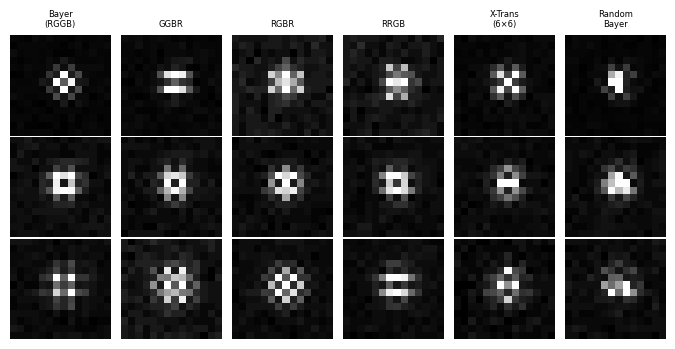

In [7]:
# ── PSF images: 3 dyes × 6 patterns ──────────────────────────────────────────
vis_image_size = 14
vis_pixel_size = 69
vis_NA         = 1.49
vis_background = 4
vis_n_photon   = 4000
vis_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
vis_filters    = []

# One representative random patch for visualisation
rng_vis = np.random.default_rng(0)
mosaic_random_vis = sample_chip_patch(chip_pattern, vis_image_size, rng_vis)

pattern_mosaics = {
    "Bayer\n(RGGB)":   mosaic_bayer,
    "GGBR":            mosaic_ggbr,
    "RGBR":            mosaic_rgbr,
    "RRGB":            mosaic_rrgb,
    "X-Trans\n(6×6)":  mosaic_xtrans,
    "Random\nBayer":   mosaic_random_vis,
}

R_eff, G_eff, B_eff, wavelength_vis = S_F.getpixelefficiency()
pixel_QYs_vis = np.vstack([B_eff, G_eff, R_eff])

x0_vis = (vis_image_size // 2) * vis_pixel_size
y0_vis = (vis_image_size // 2) * vis_pixel_size

n_patterns = len(pattern_mosaics)
n_dyes_vis = len(vis_dyes)
fig, axs = plt.subplots(
    nrows=n_dyes_vis, ncols=n_patterns,
    figsize=(6.69, 6.69 * n_dyes_vis / n_patterns),
    squeeze=False,
)

fs = plotter.config.font_size

for col, (pname, mosaic) in enumerate(pattern_mosaics.items()):
    masks_vis = M_F.get_masks(size_x=vis_image_size, size_y=vis_image_size, mosaic_unit=mosaic)
    cam_vis = {
        "gain":               np.full((vis_image_size, vis_image_size), np.median(gain)),
        "offset":             np.full((vis_image_size, vis_image_size), np.median(offset)),
        "variance":           np.full((vis_image_size, vis_image_size), np.median(variance)),
        "readnoise":          float(np.median(readnoise)),
        "rqe":                np.full((vis_image_size, vis_image_size), np.median(rqe)),
        "masks":              masks_vis,
        "pixel_QYs":          pixel_QYs_vis,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }
    for row, dye in enumerate(vis_dyes):
        ax = axs[row, col]
        aew, dpe = S_F.get_pixel_fractions_dye_and_filters(
            dye, vis_filters, wavelength_vis, pixel_QYs_vis
        )
        n_ph_vis  = {dye: np.full(1, vis_n_photon)}
        x0y0_vis  = {dye: np.zeros([1, 2, 1])}
        x0y0_vis[dye][:, :, :] = np.array([[y0_vis, x0_vis]]).T

        img, _, _ = MSF.gen_camera_image_stack(
            cam_vis, wavelength_vis,
            np.array(aew), np.array(dpe),
            n_ph_vis, x0y0_vis,
            background_photons=vis_background,
            smoothing_function=smoothing_function,
            NA=vis_NA, pixel_size=vis_pixel_size,
            return_normal_image=False,
        )
        plotter.image_plot(
            ax, img, colorbar=False,
            scalebarsize=200, pixelsize=vis_pixel_size, scalebarlabel="200 nm",
            scalebar_color="white", origin="lower",
        )
        if row == 0:
            ax.set_title(pname, fontsize=fs - 1)
        if col == 0:
            ax.set_ylabel(dye, fontsize=fs - 1)

fig.tight_layout(pad=0.3)
plt.savefig(os.path.join(save_folder_refactored, "psf_images_new_patterns.svg"),
            dpi=300, format="svg")
plt.show()

In [8]:
# ── Simulation config for new patterns ────────────────────────────────────────
sim_image_size = 14
sim_pixel_size = 69
sim_NA         = 1.49
sim_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
sim_filters    = []

n_photon_space_new = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

config_new = SimulationConfig(
    n_bootstrap=100000,
    background_photons=5.0,
    NA=sim_NA,
    pixel_size=sim_pixel_size,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

R_sim, G_sim, B_sim, wavelength_sim = S_F.getpixelefficiency()
pixel_QYs_sim = np.vstack([B_sim, G_sim, R_sim])

# One random patch (seed 42) as the representative random-Bayer pattern
rng_sim = np.random.default_rng(42)
mosaic_random_sim = sample_chip_patch(chip_pattern, sim_image_size, rng_sim)

# Pattern registry: name → (mosaic_unit, starting_flag)
sim_patterns = {
    "Bayer":        (mosaic_bayer,      "bayer_rggb_"),
    "GGBR":         (mosaic_ggbr,       "ggbr_"),
    "RGBR":         (mosaic_rgbr,       "rgbr_"),
    "RRGB":         (mosaic_rrgb,       "rrgb_"),
    "X-Trans":      (mosaic_xtrans,     "xtrans_"),
    "Random_Bayer": (mosaic_random_sim, "random_bayer_s42_"),
}

print("Simulation patterns:")
for name, (mo, flag) in sim_patterns.items():
    n = mo.size
    print(f"  {name:16s}  flag={flag!r:25s}  "
          f"R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
print(f"\nDyes: {sim_dyes}")
print(f"Photon levels: {len(n_photon_space_new)}  "
      f"({n_photon_space_new[0]:.0f}–{n_photon_space_new[-1]:.0f})")
print(f"Save folder: {save_folder_refactored}")

Simulation patterns:
  Bayer             flag='bayer_rggb_'              R=0.250  G=0.500  B=0.250
  GGBR              flag='ggbr_'                    R=0.250  G=0.500  B=0.250
  RGBR              flag='rgbr_'                    R=0.500  G=0.250  B=0.250
  RRGB              flag='rrgb_'                    R=0.500  G=0.250  B=0.250
  X-Trans           flag='xtrans_'                  R=0.222  G=0.556  B=0.222
  Random_Bayer      flag='random_bayer_s42_'        R=0.250  G=0.500  B=0.250

Dyes: ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Photon levels: 200  (500–50000)
Save folder: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260629_ArbitraryPixelPattern


In [9]:
# ── Run simulations for all new patterns × dyes ───────────────────────────────
import time as _time

n_total_new = len(sim_patterns) * len(sim_dyes)
i_new = 0
t0_new = _time.time()

for pattern_name, (mosaic, flag) in sim_patterns.items():
    masks_sim = M_F.get_masks(
        size_x=sim_image_size, size_y=sim_image_size, mosaic_unit=mosaic
    )
    cam_sim = {
        "gain":                np.full((sim_image_size, sim_image_size), np.median(gain)),
        "offset":              np.full((sim_image_size, sim_image_size), np.median(offset)),
        "variance":            np.full((sim_image_size, sim_image_size), np.median(variance)),
        "readnoise":           float(np.median(readnoise)),
        "rqe":                 np.full((sim_image_size, sim_image_size), np.median(rqe)),
        "masks":               masks_sim,
        "pixel_QYs":           pixel_QYs_sim,
        "pixel_order":         ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
        "mosaic_unit":          mosaic if pattern_name != "Random_Bayer" else None,
    }
    for dye in sim_dyes:
        i_new += 1
        print(f"[{i_new:2d}/{n_total_new}]  {pattern_name:16s}  {dye}", end="  ")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=sim_filters,
                wavelength=wavelength_sim,
                camera_parameters=cam_sim,
                save_folder=save_folder_refactored,
                n_photon_space=n_photon_space_new,
                smoothing_function=smoothing_function,
                strategy=FittingStrategy.STANDARD,
                starting_flag=flag,
                config=config_new,
                overwrite=True,
            )
            elapsed = (_time.time() - t0_new) / 60
            rate    = i_new / elapsed if elapsed > 0 else 0
            eta     = (n_total_new - i_new) / rate if rate > 0 else 0
            print(f"done  ({elapsed:.1f} min, ETA {eta:.1f} min)")
        except Exception as e:
            print(f"FAILED: {e}")

print(f"\nAll new-pattern simulations complete in {(_time.time()-t0_new)/60:.1f} min.")

simulation.multicolour — INFO — Overwrite=True: Deleting existing results file: bayer_rggb_LM_method_ATTO 488_rawresults.h5


[ 1/18]  Bayer             ATTO 488  

/home/jsb92/Documents/venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 34.810 min
simulation.multicolour — INFO — Simulation completed for strategy standard
simulation.multicolour — INFO — Overwrite=True: Deleting existing results file: bayer_rggb_LM_method_ATTO 565_rawresults.h5


done  (34.8 min, ETA 591.8 min)


...

done  (688.2 min, ETA 86.0 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 41.697 min
simulation.multicolour — INFO — Simulation completed for strategy standard
simulation.multicolour — INFO — Overwrite=True: Deleting existing results file: random_bayer_s42_LM_method_ATTO 647N_rawresults.h5


done  (729.9 min, ETA 42.9 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 42.106 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (772.1 min, ETA 0.0 min)

All new-pattern simulations complete in 772.1 min.


In [10]:
# ── Load results → build New_Patterns_XR ──────────────────────────────────────
# Dims: [pattern, dye, n_photons, metric]  metrics = ["sigma_xy", "sigma_colour"]
_all_files_new = os.listdir(save_folder_refactored)
_params_new    = ["sigma_xy", "sigma_colour"]
_pattern_names = list(sim_patterns.keys())

New_Patterns_XR = xr.DataArray(
    data=np.full(
        [len(_pattern_names), len(sim_dyes), len(n_photon_space_new), len(_params_new)],
        np.nan,
    ),
    coords={
        "pattern":   _pattern_names,
        "dye":       sim_dyes,
        "n_photons": n_photon_space_new,
        "metric":    _params_new,
    },
    dims=["pattern", "dye", "n_photons", "metric"],
)

for i_p, (pattern_name, (mosaic, flag)) in enumerate(sim_patterns.items()):
    pat_image_size = (config_new.n_unit_cells * mosaic.shape[0]
                      if pattern_name != "Random_Bayer" else sim_image_size)
    for i_d, dye in enumerate(sim_dyes):
        dye_str = dye.replace("/", "-")
        dye_files = [
            os.path.join(save_folder_refactored, f)
            for f in _all_files_new
            if f.startswith(flag) and dye_str in f
        ]
        raw_file  = [f for f in dye_files if "rawresults" in f]
        gt_file   = [f for f in dye_files if "groundtruth" in f]
        ip_file   = [f for f in dye_files if "input_parameters" in f]

        if not raw_file or not gt_file or not ip_file:
            print(f"Missing files for {pattern_name} / {dye}")
            continue

        gt    = pd.read_csv(gt_file[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / sim_pixel_size,
                           gt["y0"].to_numpy() / sim_pixel_size]).T

        dye_BGR     = pd.read_csv(ip_file[0]).to_numpy()[0][-3:]
        colour_true = np.expand_dims(dye_BGR / dye_BGR.sum(), 0)

        df_raw = pd.read_hdf(raw_file[0])

        for k, _ in enumerate(n_photon_space_new):
            sub = df_raw[df_raw["photon_level"] == k]
            filt = ~(
                (sub["xc"] < 0) | (sub["yc"] < 0) |
                (sub["s_x"] < 0) | (sub["s_y"] < 0) |
                (sub["xc"] > pat_image_size) | (sub["yc"] > pat_image_size)
            )
            if filt.sum() < 5:
                continue
            ex = sub["xc"].to_numpy()[filt] - gt_px[filt, 0]
            ey = sub["yc"].to_numpy()[filt] - gt_px[filt, 1]
            New_Patterns_XR[i_p, i_d, k, 0] = (
                np.sqrt((np.nanstd(ex)**2 + np.nanstd(ey)**2) / 2) * sim_pixel_size
            )
            colour = np.vstack([
                sub["A_B"].to_numpy()[filt],
                sub["A_G"].to_numpy()[filt],
                sub["A_R"].to_numpy()[filt],
            ]).T
            New_Patterns_XR[i_p, i_d, k, 1] = float(np.nanstd(cdist(colour, colour_true)))

New_Patterns_XR.to_netcdf(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)
print(f"Saved  shape={New_Patterns_XR.shape}  dims={list(New_Patterns_XR.dims)}")
n_valid = int(np.sum(~np.isnan(New_Patterns_XR.sel(metric="sigma_xy").values)))
print(f"{n_valid} / {New_Patterns_XR.sel(metric='sigma_xy').size} grid cells filled")

Saved  shape=(6, 3, 200, 2)  dims=['pattern', 'dye', 'n_photons', 'metric']
3600 / 3600 grid cells filled


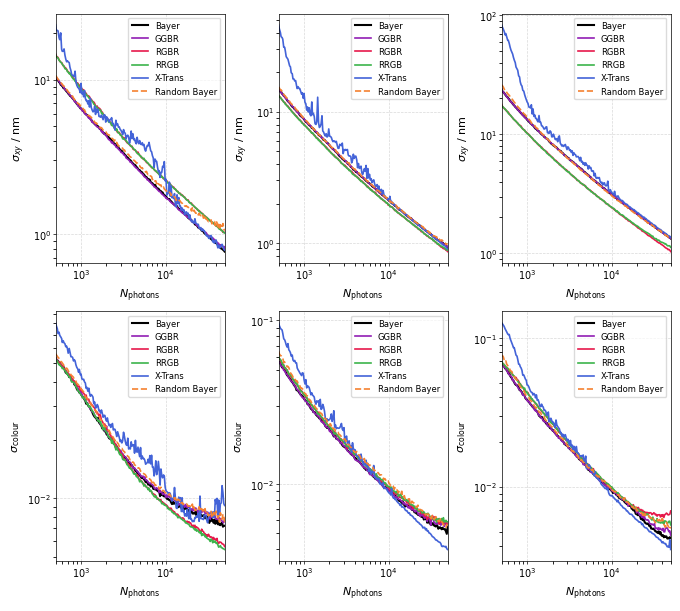

In [19]:
# ── Comparison: σ_xy and σ_colour vs N_photons, all patterns ──────────────────
New_Patterns_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)

# Colour / style per pattern — Bayer is the solid black reference line
_pattern_styles = {
    "Bayer":        dict(color="black",    linewidth=1.5, linestyle="-"),
    "GGBR":         dict(color="#911eb4",  linewidth=1.2, linestyle="-"),
    "RGBR":         dict(color="#e6194b",  linewidth=1.2, linestyle="-"),
    "RRGB":         dict(color="#3cb44b",  linewidth=1.2, linestyle="-"),
    "X-Trans":      dict(color="#4363d8",  linewidth=1.2, linestyle="-"),
    "Random_Bayer": dict(color="#f58231",  linewidth=1.2, linestyle="--"),
}

_dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']

fig, axs = plotter.two_column_plot(ncols=3, nrows=2, width_ratios=[1,1,1], height_ratios=[1,1])
fs = 8

for ax, metric, ylabel in [
    (axs[0, :], "sigma_xy",     r"$\sigma_{xy}$ / nm"),
    (axs[1, :], "sigma_colour", r"$\sigma_{\rm colour}$"),
]:
    for pattern_name, style in _pattern_styles.items():
            for d_num, dye in enumerate(_dyes):
                y = (New_Patterns_XR.sel(pattern=pattern_name, metric=metric, dye=dye))
                ax[d_num] = plotter.line_plot(ax[d_num], n_photon_space_new, y,
                    label=pattern_name.replace("_", " "), **style)

                ax[d_num].set_xscale("log")
                ax[d_num].set_yscale("log")
                ax[d_num].set_xlabel(r"$N_{\rm photons}$", fontsize=fs)
                ax[d_num].set_ylabel(ylabel, fontsize=fs)
                ax[d_num].set_xlim([n_photon_space_new[0], n_photon_space_new[-1]])
                ax[d_num].tick_params(labelsize=fs-1)
                ax[d_num].legend(loc="best", fontsize=fs - 2, framealpha=0.7)

plt.savefig(
    os.path.join(save_folder_refactored, "new_patterns_precision_comparison.svg"),
    dpi=300, format="svg",
)
plt.show()

In [18]:
fs

7